## 粒子群算法（PSO）

又称粒子群优化、微粒群算法，来源于对一个简化社会模型的模拟。“粒子”是一个折衷的说法，因为既描述的群体中的成员是没有质量、没有体积的，同时也需要描述他们的速度和加速状态。

PSO 算法最初是为了图形化地模拟鸟群运动，具有收敛速度快、参数少、算法简单易实现的优点（对高维度优化问题，比遗传算法更快收敛于最优解），但是也存在陷入局部最优解的问题，因此依赖于良好的初始化。

## 问题定义

假设我们面临一个组合优化问题，其模型可以通过以下三元组描述：

$$(S, E, N)$$

其中，

- 解空间 $S$ ：所有可行解的集合。

- 能量函数 (Energy Function) $E: S \rightarrow \mathbb{R}$ ：也称为目标函数。对于每一个解 $x \in S$ ，都有一个对应的标量值 $E(x)$ 。我们的目标是寻找全局最小解 $x^*$ ，使得：

$$\forall x \in S, \quad E(x^*) \leq E(x)$$

- 邻域结构 $N$：对于任意状态 $x$ ，存在一个邻域 $N(x) \subseteq S$ 。算法通过在 $N(x)$ 中进行扰动来产生新的候选解。

（如果你看过1.模拟退火的算法，你会发现问题定义其实都是一样的。）

## 核心机制

粒子群算法的核心在于，粒子如何决定下一步怎么走。PSO的核心思想是“跟风”。

每个粒子 $i$ 会记录2个关键信息：

1. 个体历史最优 ($pbest_i$) ：这个粒子自己曾经去过的最好的位置。可以简单理解为这个粒子在某个函数上取得的历史最小值。
2. 群体历史最优 ($gbest$) ：整个群体里所有粒子曾经去过的最好的位置。

在每一次迭代中，粒子的速度 $v$ 和位置 $x$ 按照如下公式更新：

### 速度更新公式：

$$v_{i}^{t+1} = \underbrace{w \cdot v_{i}^{t}}_{\text{惯性}} + \underbrace{c_1 \cdot r_1 \cdot (pbest_i - x_{i}^{t})}_{\text{自我认知}} + \underbrace{c_2 \cdot r_2 \cdot (gbest - x_{i}^{t})}_{\text{社会经验}}$$

- 第一项：惯性部分，由惯性权重和粒子自身速度构成，表示粒子对先前自身运动状态的信任。
- 第二项：认知部分，表示粒子本身的思考，即粒子自己经验的部分，可理解为粒子当前位置与自身历史最优位置之间的距离和方向。
- 第三项：社会部分，表示粒子之间的信息共享与合作，即来源于群体中其他优秀粒子的经验，可理解为粒子当前位置与群体历史最优位置之间的距离和方向。

最终，粒子下一步迭代的移动方向 = 惯性方向 + 个体最优方向 + 群体最优方向


### 位置更新公式：

$$x_{i}^{t+1} = x_{i}^{t} + v_{i}^{t+1}$$

即，上一步的位置 + 下一步的速度

其中，
- $w$ 是惯性权重。
- $c_1, c_2$ 是学习因子（通常取 2 左右）。
- $r_1, r_2$ 是 $[0, 1]$ 之间的随机数，增加随机性。




## 人话

假设你看不懂上面的说明，请看下面的文字。

试想一个大雾天，能见度很低，你和你的同学们站在一个巨大的玉米地里。

这片地太大了，雾太浓了，你们谁也看不清哪里有玉米。但是，你们每个人手里都有一个对讲机，并且你们每个人都有一个特殊的“感应器”，能知道脚下这块地的玉米大概有多大（计算适应度）。

PSO 赋予了你们一种特殊的行动逻辑，令你在做下一次移动方向的决定时，内心会思考3个问题：

1. 惯性 (Inertia, $w \cdot v$)：
    - 这个方向上你已经走了很远，因此你仍然继续往这个方向走。
    - 这代表了你保持现状的趋势，防止你原地打转，有助于探索未知区域。
2. 历史经验 (Cognitive, $c_1 \cdot (pbest - x)$)：
    - 你想起自己以前见过的最大的玉米，想要回那边去看看。
    - 这是你对自己过去经验的信任。
3. 跟风 (Social, $c_2 \cdot (gbest - x)$)：
    - 你的同学牢王此时在对讲机里大喊，说他那有个超大的玉米。你一看，确实挺大嗷
    - 这是你对集体智慧的信任。

你的最终路线，就是这三种力量“拉扯”的结果：

- 你想保持直行（惯性）。

- 你想往回走去自己的宝地（个体最优）。

- 你想往那个大神的方向凑（全局最优）。

实际中，你的方向就是这三个**方向的叠加，在空间中描述为向量的加和**。最终，大家都会聚集到牢王、甚至比牢王发现的还要好的地方。

### 为什么要搞这么复杂的三个部分相加？

直观来看，你可以把这看作是向量合成。如果 $w$ 很大（惯性大）：像开重型卡车，方向盘打不动。这时候大家都在满场飞奔，很容易发现新大陆（全局搜索能力强），但也容易冲过头，错失目标；

如果 $w$ 很小：像开碰碰车，说停就停。大家很快就会聚到老王身边，但这可能只是个局部的小土坡，真正的珠穆朗玛峰在另一边没人去（容易陷入局部最优）。

如果 $c_1=0$（没有自我）：这是一个“毫无主见”的群体，所有人一窝蜂涌向当前的最优点。

如果 $c_2=0$（没有社会）：这是一群“闭门造车”的家伙，大家各玩各的，基本就是并发运行的多个随机搜索。

PSO 的精髓就在于平衡，既有冲劲（探索），又要有“听人劝吃饱饭”的觉悟（收敛）。

## 参数的选择

1. 粒子群规模 $N$ 

一个正整数，推荐取值范围：[20,1000]，简单问题一般取20~40，较难或特定类别的问题可以取100~200。较小的种群规模容易陷入局部最优；较大的种群规模可以提高收敛性，更快找到全局最优解，但是相应地每次迭代的计算量也会增大；当种群规模增大至一定水平时，再增大将不再有显著的作用。

2. 粒子维度 $D$

粒子搜索的空间维数即为自变量的个数。

3. 迭代次数：$K$ 

推荐取值范围：[50,100]，典型取值：60、70、100；这需要在优化的过程中根据实际情况进行调整，迭代次数太小的话解不稳定，太大的话非常耗时，没有必要。

4. 惯性权重 $w$

惯性权重使粒子保持运动的惯性和搜索扩展空间的趋势。值越大，探索新区域的能力越强，全局寻优能力越强，但是局部寻优能力越弱。反之，全局寻优能力越弱，局部寻优能力强。较大的 $w$ 有利于全局搜索，跳出局部极值，不至于陷入局部最优；而较小的有利于局部搜索，让算法快速收敛到最优解。

当问题空间较大时，为了在搜索速度和搜索精度之间达到平衡，通常做法是使算法在前期有较高的全局搜索能力以得到合适的种子，而在后期有较高的局部搜索能力以提高收敛精度，所以不宜为一个固定的常数。

**改善惯性权重**

在解决实际优化问题时，往往希望先采用全局搜索，使搜索空间快速收敛于某一区域，然后采用局部精细搜索以获得高精度的解。因此提出了自适应调整的策略，即随着迭代的进行，线性地减小的值。这里提供一个简单常用的方法——线性变化策略：随着迭代次数的增加，惯性权重不断减小，从而使得粒子群算法在初期具有较强的全局收敛能力，在后期具有较强的局部收敛能力：

$$\omega = \omega_{\max} - (\omega_{\max} - \omega_{\min}) \frac{\text{iter}}{\text{iter}_{\max}}$$


当然，调整权重的方法有很多，也不一定是线性的，你完全可以自己尝试不同的动态权重调整方法。

**改善学习因子**$c_1$ , $c_2$ (也称为加速系数或加速因子)

低的值使粒子在目标区域外徘徊，而高的值导致粒子越过目标区域。推荐取值范围：
$[0,4]$；典型取值：$c_1 = c_2 = 2$、$c_1 = 1.6$ 和 $c_2 = 1.8$、$c_1 = 1.6$ 和 $c_2 = 2$，针对不同的问题有不同的取值，一般通过在一个区间内试凑来调整这两个值。

### 写在最后

粒子群算法优化的结果受很多因素的影响，其中受粒子初始值的影响比较大，而且较难调控。如果粒子初始值是随机初始化的，在不改变任何参数的情况下，多次优化的结果不一定都收敛到一个全局或局部最优解，也可能会得到一个无效解。所以粒子初始化是一个十分重要的步骤，它关系到整个优化过程中优化收敛的速度与方向。如果粒子的初始化范围选择得好的话可以大大缩短优化的收敛时间，也不易陷入局部最优解。需要根据具体的问题进行分析，如果根据经验判断出最优解一定在某个范围内，则就在这个范围内初始化粒子。如果无法确定，则以粒子的取值边界作为初始化范围。

收敛性的数学证明帮助了 PSO 的发展和应用，，但此类分析具有很大的局限性。为 PSO 加入正交学习后，算法的全局收敛、收敛精度及稳健可靠性都得到了提高。 近年来，为了提升PSO求解大规模高维优化问题的能力，竞争学习PSO（Competitive Swarm Optimizer，CSO）和[层次学习（Level-based Swarm Optimizer，LLSO）](https://ieeexplore.ieee.org/document/8025724)等相继被提出，被从理论和数值实验验证了算法平衡全局探索和局部开发的能力。 此外，在分布式多智能体的共识优化场景中，[基于内外部学习机制的PSO算法（Multi-Agent Swarm Optimization With Adaptive Internal and External Learning，MASOIE）](https://ieeexplore.ieee.org/document/10477458)也被提出，并在理论上证明了该方法的共识收敛性。

如果你对这个算法很感兴趣，可以去[格拉斯哥大学的交互式群体演化在线学习课件 EA_demo](https://web.archive.org/web/20160507233728/http://userweb.eng.gla.ac.uk/yun.li/ga_demo/)，可以帮助读者更好地理解进化及粒群算法，允许用户直接在网页上一代一代地手动运行，以看进化算法是怎样一步一步操作的，亦可在背景中批量运行，以观察算法的收敛和个体是否跳出局部最优。

以及一篇[利用多目标优化方法自动校准快速洪水扩散模型](https://link.springer.com/article/10.1007/s00500-012-0944-z)。

In [10]:
def demo_func(x):
    x1, x2 = x
    return -20 * np.exp(-0.2 * np.sqrt(0.5 * (x1 ** 2 + x2 ** 2))) - np.exp(
        0.5 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2))) + 20 + np.e

best_x is  [9.52556534e-01 3.03092073e-04] best_y is [2.5799337]


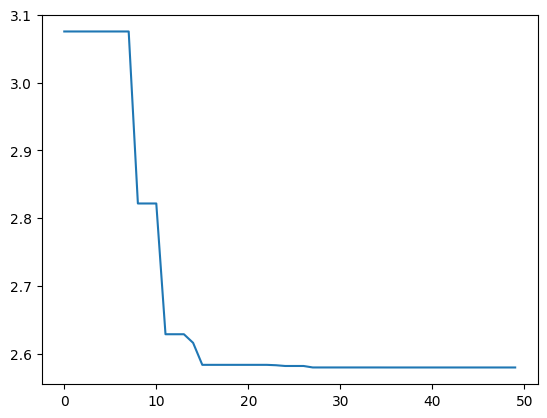

In [15]:
from sko.PSO import PSO
import matplotlib.pyplot as plt

pso = PSO(func=demo_func, n_dim=2, pop=40, max_iter=max_iter, lb=[-2, -2], ub=[2, 2]
          , constraint_ueq=constraint_ueq)
pso.run()
print('best_x is ', pso.gbest_x, 'best_y is', pso.gbest_y)

# 画出迭代过程中全局最优值的变化趋势
plt.plot(pso.gbest_y_hist)
plt.show()

### 以下是迭代图：

![](pso.gif)

绘制迭代图的完整代码可以去[这个网站](https://github.com/guofei9987/scikit-opt/blob/master/examples/demo_pso_ani.py)看。
